<a href="https://colab.research.google.com/github/rushisarena/aqi-asthma-montecarlo/blob/main/AQI_Asthma_Simulatio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.makedirs("outputs", exist_ok=True)
os.makedirs("data", exist_ok=True)
print("Folders ready.")

Folders ready.


In [2]:
AQI_REAL_MEAN = 95
AQI_REAL_STD = 28

AQI_HIGH_MEAN = AQI_REAL_MEAN + 2 * AQI_REAL_STD
AQI_HIGH_STD = AQI_REAL_STD * 1.2

In [3]:

# Define all model functions



import numpy as np

np.random.seed(42) # reproducibility
N = 10_000 # Monte Carlo samples
K = 10 # sigmoid steepness
def sigmoid(x, k=K):
    """Maps any real number cleanly into (0, 1)."""
    return 1.0 / (1.0 + np.exp(-k * x))
def sample_aqi(mean, std, n):
    """Real-data-derived: Normal(mean, std) clipped to [0, 500]."""
    return np.clip(np.random.normal(mean, std, n), 0, 500)
def sample_exposure(n):
    """Synthetic: Uniform[0.5, 1.5] -- outdoor time fraction."""
    return np.random.uniform(0.5, 1.5, n)
def sample_sensitivity(n):
    """Synthetic: Beta(2, 5) in [0, 1] -- respiratory sensitivity."""
    return np.random.beta(2, 5, n)
def compute_risk(aqi, E, S):
    """
    raw_score = (AQI / 500) * E * S
    risk = sigmoid(raw_score - 0.5)
    """
    raw = (aqi / 500.0) * E * S
    return sigmoid(raw - 0.5)

In [4]:
# Sanity-check the model on 5 samples before looping

test_aqi = sample_aqi(AQI_REAL_MEAN, AQI_REAL_STD, 5)
test_E = sample_exposure(5)
test_S = sample_sensitivity(5)
test_r = compute_risk(test_aqi, test_E, test_S)

for i in range(5):
    print(f"AQI={test_aqi[i]:.0f} E={test_E[i]:.2f} "
          f"S={test_S[i]:.2f} Risk={test_r[i]:.4f}")

AQI=109 E=0.56 S=0.27 Risk=0.0093
AQI=91 E=1.37 S=0.32 Risk=0.0148
AQI=113 E=1.10 S=0.07 Risk=0.0080
AQI=138 E=1.21 S=0.20 Risk=0.0128
AQI=88 E=0.52 S=0.28 Risk=0.0086


In [5]:
# Run the full simulation for both scenarios


def run_monte_carlo(aqi_mean, aqi_std, n=N):
  aqi = sample_aqi(aqi_mean, aqi_std, n) # real-data-derived params
  E = sample_exposure(n) # synthetic
  S = sample_sensitivity(n) # synthetic
  risk = compute_risk(aqi, E, S)
  return {"aqi": aqi, "E": E, "S": S, "risk": risk}

results_normal = run_monte_carlo(AQI_REAL_MEAN, AQI_REAL_STD)
results_high = run_monte_carlo(AQI_HIGH_MEAN, AQI_HIGH_STD)
print("Simulation complete — 10,000 samples per scenario.")

Simulation complete — 10,000 samples per scenario.


In [6]:
# Print summary statistics


def summarise(label, r):
  risk = r["risk"]
  print(f"\n{'='*40}")
  print(f" {label}")
  print(f"{'='*40}")
  print(f" Mean risk : {risk.mean():.4f}")
  print(f" Std risk : {risk.std():.4f}")
  print(f" Median : {np.median(risk):.4f}")
  print(f" 95th percentile : {np.percentile(risk, 95):.4f}")
  print(f" P(risk > 0.5) : {(risk > 0.5).mean():.4f}")
  print(f" P(risk > 0.6) : {(risk > 0.6).mean():.4f}")
  summarise("Normal AQI scenario", results_normal)
  summarise("High AQI scenario", results_high)
  print(f"\nMean risk increase: "
  f"{results_high['risk'].mean()-results_normal['risk'].mean():.4f}")

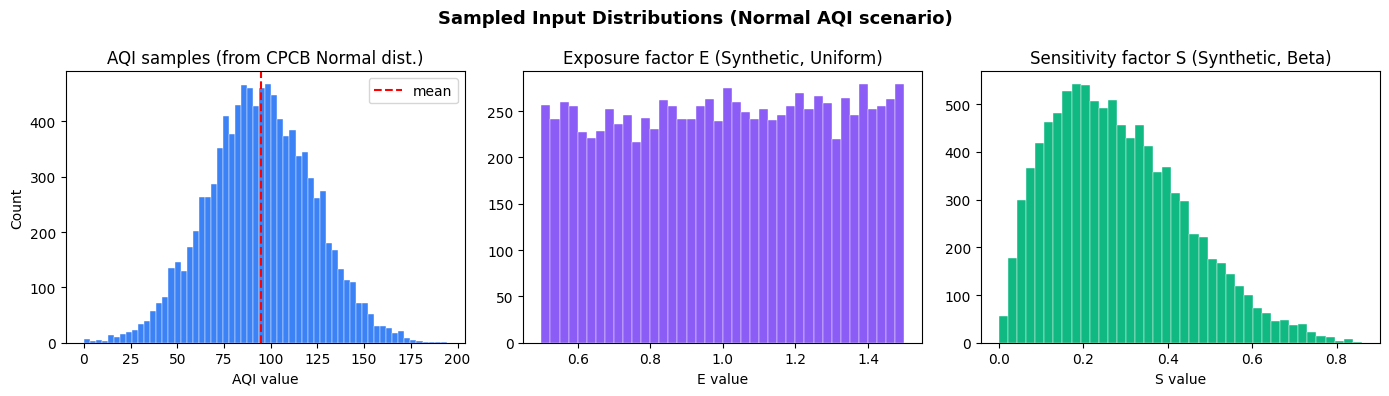

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [7]:
# Input distributions (AQI, Exposure, Sensitivity)

import matplotlib.pyplot as plt



fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Sampled Input Distributions (Normal AQI scenario)",
fontsize=13, fontweight="bold")
axes[0].hist(results_normal["aqi"], bins=60, color="#3B82F6",
edgecolor="white", linewidth=0.3)
axes[0].set_title("AQI samples (from CPCB Normal dist.)")
axes[0].set_xlabel("AQI value")
axes[0].axvline(results_normal["aqi"].mean(), color="red",
lw=1.5, ls="--", label="mean")
axes[0].legend()
axes[1].hist(results_normal["E"], bins=40, color="#8B5CF6",
edgecolor="white", linewidth=0.3)
axes[1].set_title("Exposure factor E (Synthetic, Uniform)")
axes[1].set_xlabel("E value")
axes[2].hist(results_normal["S"], bins=40, color="#10B981",
edgecolor="white", linewidth=0.3)
axes[2].set_title("Sensitivity factor S (Synthetic, Beta)")
axes[2].set_xlabel("S value")
for ax in axes:
  ax.set_ylabel("Count")
  plt.tight_layout()
  plt.savefig("outputs/plot1_inputs.png", dpi=150, bbox_inches="tight")
  plt.show()

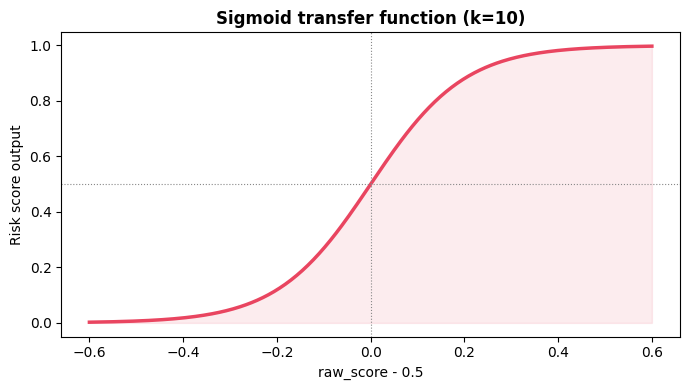

In [8]:
# Sigmoid transfer function



fig, ax = plt.subplots(figsize=(7, 4))
raw_x = np.linspace(-0.6, 0.6, 400)
sig_y = sigmoid(raw_x)
ax.plot(raw_x, sig_y, color="#E94560", lw=2.5)
ax.fill_between(raw_x, sig_y, alpha=0.1, color="#E94560")
ax.axvline(0, color="#888", lw=0.8, ls=":")
ax.axhline(0.5, color="#888", lw=0.8, ls=":")
ax.set_xlabel("raw_score - 0.5")
ax.set_ylabel("Risk score output")
ax.set_title("Sigmoid transfer function (k=10)", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plot2_sigmoid.png", dpi=150, bbox_inches="tight")
plt.show()

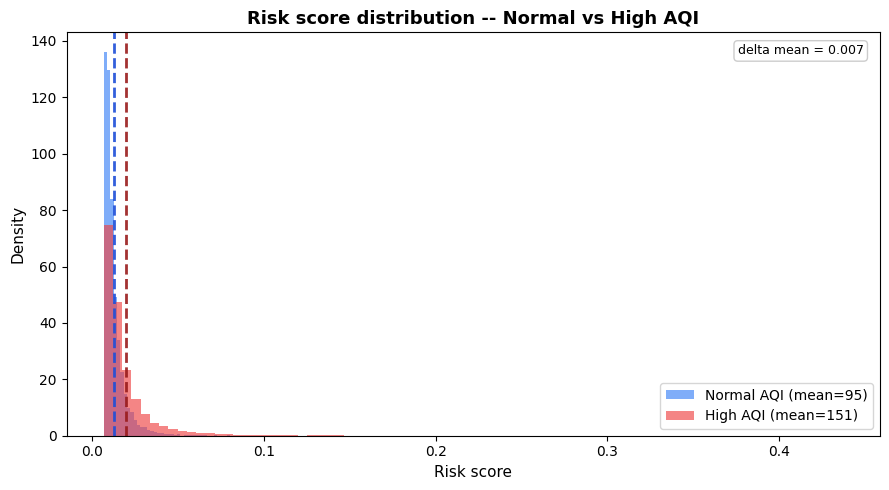

In [9]:
# Risk score distributions: Normal vs High AQI




fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(results_normal["risk"], bins=80, density=True, alpha=0.65,
color="#3B82F6", label=f"Normal AQI (mean={AQI_REAL_MEAN:.0f})")
ax.hist(results_high["risk"], bins=80, density=True, alpha=0.65,
color="#EF4444", label=f"High AQI (mean={AQI_HIGH_MEAN:.0f})")
for res, col in [(results_normal,"#1D4ED8"),(results_high,"#991B1B")]:
    ax.axvline(res["risk"].mean(), color=col, lw=2, ls="--", alpha=0.9)
ax.set_xlabel("Risk score", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Risk score distribution -- Normal vs High AQI",
fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
delta = results_high['risk'].mean() - results_normal['risk'].mean()
ax.text(0.98, 0.97, f"delta mean = {delta:.3f}",
ha="right", va="top", transform=ax.transAxes, fontsize=9,
bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#ccc"))
plt.tight_layout()
plt.savefig("outputs/plot3_risk_dist.png", dpi=150, bbox_inches="tight")
plt.show()

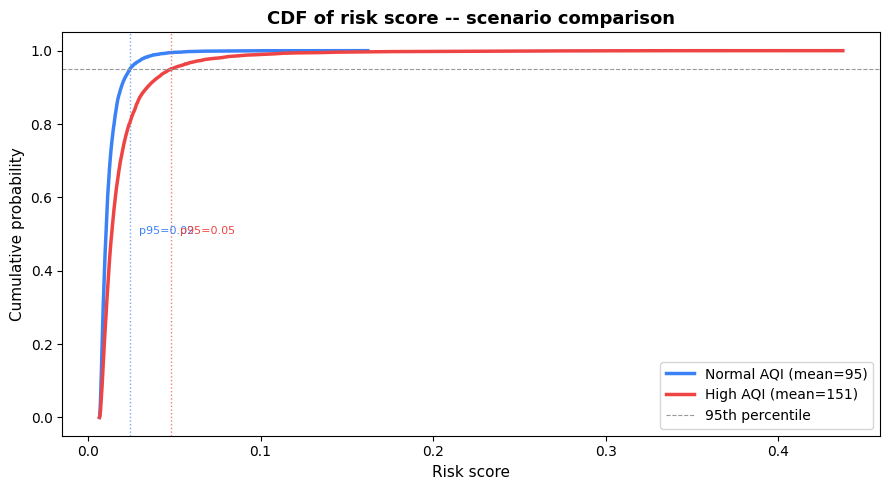

In [10]:
# Cumulative distribution function (CDF)



fig, ax = plt.subplots(figsize=(9, 5))
for res, col, label in [
(results_normal, "#3B82F6", f"Normal AQI (mean={AQI_REAL_MEAN:.0f})"),
(results_high, "#EF4444", f"High AQI (mean={AQI_HIGH_MEAN:.0f})")
]:
    sorted_r = np.sort(res["risk"])
    cdf = np.arange(1, N+1) / N
    ax.plot(sorted_r, cdf, color=col, lw=2.5, label=label)
    p95 = np.percentile(res["risk"], 95)
    ax.axvline(p95, color=col, lw=1, ls=":", alpha=0.7)
    ax.text(p95+0.005, 0.5, f"p95={p95:.2f}", color=col, fontsize=8)
ax.axhline(0.95, color="#999", lw=0.8, ls="--", label="95th percentile")
ax.set_xlabel("Risk score", fontsize=11)
ax.set_ylabel("Cumulative probability", fontsize=11)
ax.set_title("CDF of risk score -- scenario comparison",
fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("outputs/plot4_cdf.png", dpi=150, bbox_inches="tight")
plt.show()

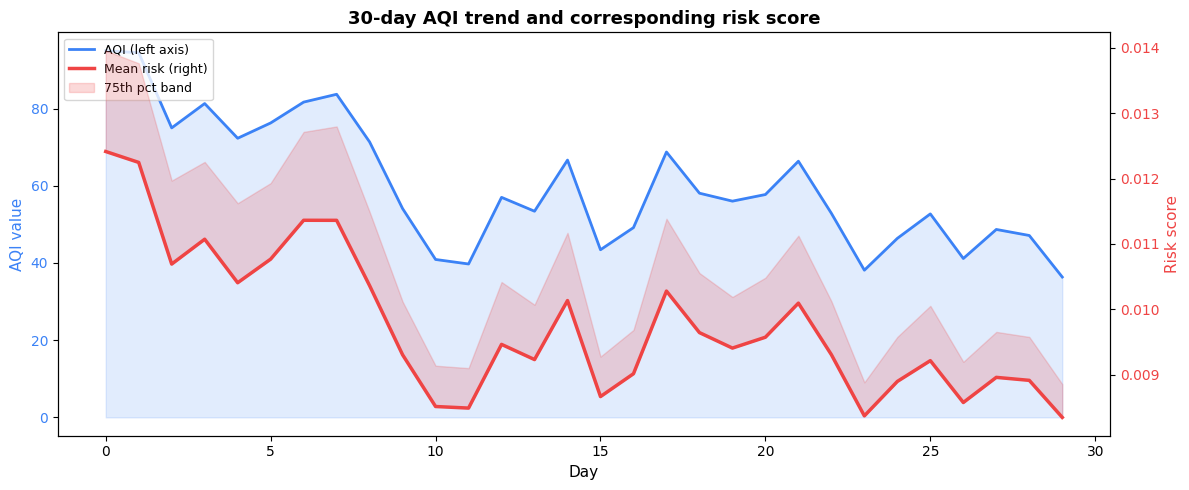

In [11]:
# 30-day time series (bonus)



days = 30
aqi_ts = np.zeros(days)
aqi_ts[0] = AQI_REAL_MEAN
for d in range(1, days):
    aqi_ts[d] = np.clip(aqi_ts[d-1] + np.random.normal(0, 12), 0, 500)
daily_risk_mean, daily_risk_p75 = [], []
for aqi_val in aqi_ts:
    r = run_monte_carlo(aqi_val, AQI_REAL_STD * 0.3, n=2000)["risk"]
    daily_risk_mean.append(r.mean())
    daily_risk_p75.append(np.percentile(r, 75))
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.fill_between(range(days), aqi_ts, alpha=0.15, color="#3B82F6")
ax1.plot(aqi_ts, color="#3B82F6", lw=2, label="AQI (left axis)")
ax1.set_ylabel("AQI value", color="#3B82F6", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#3B82F6")
ax2.plot(daily_risk_mean, color="#EF4444", lw=2.5, label="Mean risk (right)")
ax2.fill_between(range(days), daily_risk_mean, daily_risk_p75,
alpha=0.2, color="#EF4444", label="75th pct band")
ax2.set_ylabel("Risk score", color="#EF4444", fontsize=11)
ax2.tick_params(axis="y", labelcolor="#EF4444")
ax1.set_xlabel("Day", fontsize=11)
ax1.set_title("30-day AQI trend and corresponding risk score",
fontsize=13, fontweight="bold")
l1,la1 = ax1.get_legend_handles_labels()
l2,la2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, la1+la2, loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/plot5_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()